# **BƯỚC 1: Kết nối Google Drive và Cấu hình**

In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os

# CẤU HÌNH ĐƯỜNG DẪN (sửa ở đây nếu cần)
drive_data_path = '/content/drive/MyDrive/Project_CV/Student-engagement-dataset-clean'
model_path_h5 = '/content/drive/MyDrive/Project_CV/CNN_feature.h5'
svm_save_path = '/content/drive/MyDrive/Project_CV/svm_final_model.pkl'
temp_dir = '/content/temp_svm_data'

print("Đã kết nối Drive thành công!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Đã kết nối Drive thành công!


## **BƯỚC 2: Tự động chia dữ liệu (80% Train - 20% Test)**

In [4]:
import shutil
import random

if os.path.exists(temp_dir):
    shutil.rmtree(temp_dir)

for root_folder in os.listdir(drive_data_path):
    root_path = os.path.join(drive_data_path, root_folder)
    if not os.path.isdir(root_path):
        continue

    for class_name in os.listdir(root_path):
        class_path = os.path.join(root_path, class_name)
        if not os.path.isdir(class_path):
            continue

        train_out = os.path.join(temp_dir, 'train', class_name)
        test_out  = os.path.join(temp_dir, 'test', class_name)
        os.makedirs(train_out, exist_ok=True)
        os.makedirs(test_out, exist_ok=True)

        images = [f for f in os.listdir(class_path)
                  if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        random.shuffle(images)

        split = int(0.8 * len(images))
        for img in images[:split]:
            shutil.copy(os.path.join(class_path, img), os.path.join(train_out, img))
        for img in images[split:]:
            shutil.copy(os.path.join(class_path, img), os.path.join(test_out, img))

print("Dataset ready:", temp_dir)

Dataset ready: /content/temp_svm_data


# **BƯỚC 3: Load ảnh**

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    os.path.join(temp_dir, 'train'),
    target_size=IMG_SIZE,
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

test_gen = datagen.flow_from_directory(
    os.path.join(temp_dir, 'test'),
    target_size=IMG_SIZE,
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

y_train = train_gen.classes
y_test  = test_gen.classes

Found 1694 images belonging to 6 classes.
Found 426 images belonging to 6 classes.


# **BƯỚC 4: Load CNN_feature.h5**

In [6]:
from tensorflow.keras.models import load_model

feature_model = load_model(model_path_h5)
feature_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 512)            │    33,554,944 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,717,376 (132.44 MB)

 Trainable params: 34,717,376 (132.44 MB)

 Non-trainable params: 0 (0.00 B)

# **BƯỚC 5: Trích xuất feature**

In [7]:
X_train = feature_model.predict(train_gen, verbose=1)
X_test  = feature_model.predict(test_gen, verbose=1)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


53/53 ━━━━━━━━━━━━━━━━━━━━ 55s 989ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 947ms/step
(1694, 512) (1694,)
(426, 512) (426,)


# **BƯỚC 6: Train SVM**

In [8]:
from sklearn.svm import SVC
import joblib

svm_model = SVC(kernel='rbf', C=1.0)
svm_model.fit(X_train, y_train)

joblib.dump(svm_model, svm_save_path)
print("Train SVM xong & đã lưu model")

Train SVM xong & đã lưu model


# **BƯỚC 7: Đánh giá**

Accuracy (CNN feature + SVM): 96.95%


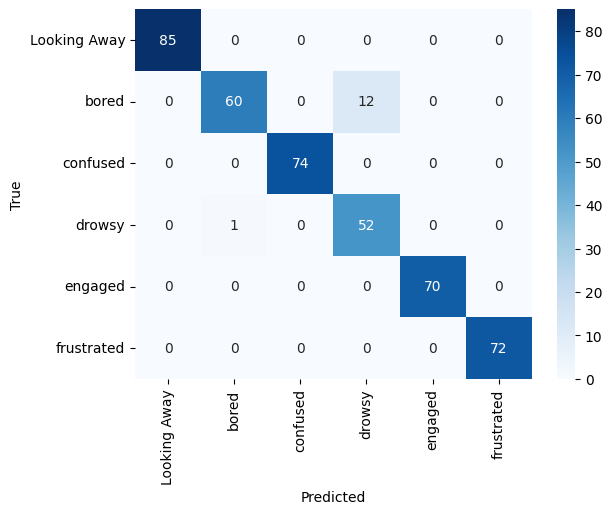

              precision    recall  f1-score   support

Looking Away       1.00      1.00      1.00        85
       bored       0.98      0.83      0.90        72
    confused       1.00      1.00      1.00        74
      drowsy       0.81      0.98      0.89        53
     engaged       1.00      1.00      1.00        70
  frustrated       1.00      1.00      1.00        72

    accuracy                           0.97       426
   macro avg       0.97      0.97      0.97       426
weighted avg       0.97      0.97      0.97       426



In [11]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = svm_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy (CNN feature + SVM): {acc*100:.2f}%")

class_names = list(test_gen.class_indices.keys())

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print(classification_report(y_test, y_pred, target_names=class_names))
